
# 📊 Olist Ecommerce Dataset – Wrangling Summary

## Overview
The Olist dataset is a large Brazilian ecommerce dataset containing multiple CSV files that describe the full order lifecycle: customers, orders, products, sellers, payments, reviews, and geolocation.  
Our wrangling process cleaned, transformed, and integrated these files into a structured staging schema for analytics.

---

## Datasets and Wrangling Steps

### 1. **olist_orders_dataset.csv**
- Contains order IDs, customer IDs, order status, timestamps (purchase, approval, delivery).
- Wrangling:
  - Converted timestamps to proper datetime format.
  - Derived delivery time and order lifecycle durations.
  - Filtered cancelled/unavailable orders for clean analysis.

### 2. **olist_customers_dataset.csv**
- Contains customer IDs, unique identifiers, and location (city, state, zip).
- Wrangling:
  - Removed duplicates (same customer appearing multiple times).
  - Standardized city/state names.
  - Linked customers to orders via `customer_id`.

### 3. **olist_order_items_dataset.csv**
- Contains product IDs, seller IDs, order IDs, shipping limits, prices, freight values.
- Wrangling:
  - Joined with products table to enrich with category info.
  - Calculated total order value (price + freight).
  - Checked for missing product IDs.

### 4. **olist_products_dataset.csv**
- Contains product IDs, category names (Portuguese), dimensions, weights.
- Wrangling:
  - Added English translations (`product_category_name_english`).
  - Cleaned nulls in dimensions/weights.
  - Standardized product categories.

### 5. **olist_sellers_dataset.csv**
- Contains seller IDs and location info.
- Wrangling:
  - Standardized city/state names.
  - Linked sellers to order items for seller-level analytics.

### 6. **olist_order_payments_dataset.csv**
- Contains payment type, installments, and values.
- Wrangling:
  - Normalized payment types (credit card, boleto, etc.).
  - Aggregated multiple payments per order.
  - Derived average payment value per installment.

### 7. **olist_order_reviews_dataset.csv**
- Contains customer reviews, scores, comments, timestamps.
- Wrangling:
  - Converted timestamps to datetime.
  - Cleaned text fields (removed nulls, standardized encoding).
  - Derived sentiment metrics from review scores.

### 8. **olist_geolocation_dataset.csv**
- Contains latitude/longitude for customer and seller zip codes.
- Wrangling:
  - Mapped geolocation to customers and sellers.
  - Enabled spatial analysis (delivery distance, regional demand).

---

## ✅ Outcomes
- Integrated staging tables in SQL Server (`stg_orders`, `stg_customers`, `stg_products`, etc.).
- Added English translations for product categories.
- Derived key metrics:
  - Delivery times, order values, payment behavior.
  - Customer distribution by region.
  - Seller performance.
  - Review sentiment.
- Dataset is now clean, consistent, and ready for advanced analytics and modeling.

---

## 🔹 Notes
- Large DataFrames pushed to SQL Server using `to_sql` with `chunksize=1000`.
- Bulk updates used `UPDATE ... FROM` joins to avoid row-by-row loops.
- Schema modifications (e.g., adding `product_category_name_english`) documented in SQL scripts.


Step 1: Import the python Libraries

In [1]:
# Import required libraries
import pandas as pd
import os
import pyodbc   # for connecting to SQL Server



Step 2: Define Path for the dataset csv

In [2]:
# Define the folder path where all 9 CSVs are stored
data_path = r"C:\Users\HP\Downloads\E_commerce raw data"


Step 3: Load  Files (one after the other)

## Step 3: Load Orders Dataset
Here we load the raw CSV file into a Pandas DataFrame for cleaning and transformation.

1. (Orders dataset)

In [3]:
# Load the orders dataset into a Pandas DataFrame
orders = pd.read_csv(os.path.join(data_path, "olist_orders_dataset.csv"))


In [4]:
# Check how many nulls per column
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
# Check if the entire dataset has any nulls at all
orders.isnull().values.any()


True

In [6]:
# See rows with missing values
orders[orders.isnull().any(axis=1)]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [7]:

# Inspect the dataset
print(orders.head())   # preview first 5 rows
print(orders.info())   # check column types and missing values


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

2 : Convert Date Columns

In [8]:
# Convert all timestamp columns to datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])


3: Handle Missing Values

In [9]:
# Check missing values count
print(orders.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [10]:
# Step 1: Flag missing values
# This helps us keep track of which rows had missing data originally
orders['missing_approved_at'] = orders['order_approved_at'].isnull()
orders['missing_carrier_date'] = orders['order_delivered_carrier_date'].isnull()
orders['missing_customer_date'] = orders['order_delivered_customer_date'].isnull()

In [11]:
# Step 2: Handle missing 'order_approved_at'
# Business logic: approval usually happens right after purchase
# Impute missing approvals with purchase timestamp
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])

In [12]:
# Step 3: Handle missing 'order_delivered_carrier_date'
# Null means the order was never shipped
# Keep as NaT (Not a Time) so we can analyze undelivered orders later
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])

In [13]:
# Step 4: Handle missing 'order_delivered_customer_date'
# Null means the order was never delivered
# Keep as NaT so we can calculate delivery success rate
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [14]:
# Step 5: Convert estimated delivery date
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

## Business Context on order dataset

The Orders dataset captures the full lifecycle of customer purchases, from order placement to delivery.  
Feature engineering here ensures that we can measure operational efficiency and customer experience.

Key engineered features:
- **Delivery Time (days)**: Calculated as the difference between purchase and delivery dates.  
  → Helps operations track average delivery speed and identify bottlenecks.  
- **Delayed Flag**: Indicates whether an order was delivered later than the estimated date.  
  → Critical for customer satisfaction analysis and service-level agreements.  
- **Aggregated KPIs**: Metrics such as total orders, delayed orders, and average delivery time.  
  → Provide executives with high-level insights into performance trends.  

This step transforms raw timestamps into actionable KPIs that directly support:
- **Customer Experience Monitoring**: Detecting late deliveries and improving service.  
- **Operational Strategy**: Optimizing logistics and reducing delays.  
- **Business Growth**: Reliable KPIs build trust in dashboards used by leadership.





4. Feature Engineering in order dataset

In [15]:
# Step 1: Calculate delivery lead time
# This measures how many days it took from purchase to delivery
# If 'order_delivered_customer_date' is missing (NaT), the result will also be NaN
orders['delivery_lead_time'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

In [16]:
# Step 2: Flag late deliveries
# True if the actual delivery date is later than the estimated delivery date
# NaT values will result in False automatically
orders['late_delivery'] = orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']

In [17]:
# Step 3: Flag undelivered orders
# Useful for KPIs like delivery success rate
orders['undelivered'] = orders['order_delivered_customer_date'].isnull()

In [18]:
# Step 4: Inspect new features
print(orders[['order_id','delivery_lead_time','late_delivery','undelivered']].head())

                           order_id  delivery_lead_time  late_delivery  \
0  e481f51cbdc54678b7cc49136f2d6af7                 8.0          False   
1  53cdb2fc8bc7dce0b6741e2150273451                13.0          False   
2  47770eb9100c2d0c44946d9cf07ec65d                 9.0          False   
3  949d5b44dbf5de918fe9c16f97b45f8a                13.0          False   
4  ad21c59c0840e6cb83a9ceb5573f8159                 2.0          False   

   undelivered  
0        False  
1        False  
2        False  
3        False  
4        False  


In [19]:
# Days between approval and carrier pickup
orders['approval_to_carrier_days'] = (
    orders['order_delivered_carrier_date'] - orders['order_approved_at']
).dt.days

# Days between carrier pickup and customer delivery
orders['carrier_to_customer_days'] = (
    orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']
).dt.days

# Difference between actual and estimated delivery
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days


In [20]:
print(orders.duplicated().sum())
orders[orders.duplicated()].head()


0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,missing_approved_at,missing_carrier_date,missing_customer_date,delivery_lead_time,late_delivery,undelivered,approval_to_carrier_days,carrier_to_customer_days,delivery_delay_days


5. Aggregate KPIs (for analysis)

In [21]:
# % of late deliveries
late_rate = orders['late_delivery'].mean() * 100

# % of undelivered orders
undelivered_rate = orders['undelivered'].mean() * 100

# Average delivery lead time
avg_lead_time = orders['delivery_lead_time'].mean()

print(f"Late Delivery Rate: {late_rate:.2f}%")
print(f"Undelivered Rate: {undelivered_rate:.2f}%")
print(f"Average Delivery Lead Time: {avg_lead_time:.2f} days")


Late Delivery Rate: 7.87%
Undelivered Rate: 2.98%
Average Delivery Lead Time: 12.09 days


6. Save Cleaned order Dataset

In [22]:
# Save cleaned orders dataset to CSV
orders.to_csv(r"C:\Users\HP\Downloads\E_commerce raw data\orders_clean.csv", index=False)


In [23]:
print(orders.columns)


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'missing_approved_at', 'missing_carrier_date', 'missing_customer_date',
       'delivery_lead_time', 'late_delivery', 'undelivered',
       'approval_to_carrier_days', 'carrier_to_customer_days',
       'delivery_delay_days'],
      dtype='object')


7. Connection string with your server name

In [24]:
import pyodbc

# Connection string with your server name
conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=DESKTOP-HRV6DMT\\SQLEXPRESS;'   # <-- your server name
    'DATABASE=ecommerce;'                   # <-- your database name
    'Trusted_Connection=yes;'               # Windows authentication
)

cursor = conn.cursor()


8: Create Staging Table

In [25]:
cursor.execute("""
IF OBJECT_ID('stg_orders', 'U') IS NOT NULL DROP TABLE stg_orders;
CREATE TABLE stg_orders (
    order_id NVARCHAR(50),
    customer_id NVARCHAR(50),
    order_status NVARCHAR(50),
    order_purchase_timestamp DATETIME,
    order_approved_at DATETIME,
    order_delivered_carrier_date DATETIME,
    order_delivered_customer_date DATETIME,
    order_estimated_delivery_date DATETIME,
    delivery_lead_time INT,
    late_delivery BIT,
    undelivered BIT,
    approval_to_carrier_days INT,
    carrier_to_customer_days INT,
    delivery_delay_days INT,
    missing_approved_at BIT,
    missing_carrier_date BIT,
    missing_customer_date BIT
)
""")
conn.commit()


10 : Insert Cleaned Data in a stage table

In [26]:
def safe_datetime(val):
    return None if pd.isnull(val) else val

for index, row in orders.iterrows():
    cursor.execute("""
        INSERT INTO stg_orders (
            order_id, customer_id, order_status,
            order_purchase_timestamp, order_approved_at,
            order_delivered_carrier_date, order_delivered_customer_date,
            order_estimated_delivery_date, missing_approved_at,
            missing_carrier_date, missing_customer_date,
            delivery_lead_time, late_delivery, undelivered,
            approval_to_carrier_days, carrier_to_customer_days,
            delivery_delay_days
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """,
    row['order_id'], row['customer_id'], row['order_status'],
    safe_datetime(row['order_purchase_timestamp']), safe_datetime(row['order_approved_at']),
    safe_datetime(row['order_delivered_carrier_date']), safe_datetime(row['order_delivered_customer_date']),
    safe_datetime(row['order_estimated_delivery_date']), int(row['missing_approved_at']),
    int(row['missing_carrier_date']), int(row['missing_customer_date']),
    None if pd.isnull(row['delivery_lead_time']) else int(row['delivery_lead_time']),
    int(row['late_delivery']), int(row['undelivered']),
    None if pd.isnull(row['approval_to_carrier_days']) else int(row['approval_to_carrier_days']),
    None if pd.isnull(row['carrier_to_customer_days']) else int(row['carrier_to_customer_days']),
    None if pd.isnull(row['delivery_delay_days']) else int(row['delivery_delay_days']))
    
conn.commit()


 2. Next file Customer dataset,

In [27]:
# Customers table: contains customer IDs and location info
customers = pd.read_csv(os.path.join(data_path, "olist_customers_dataset.csv"))

print(customers.head())
print(customers.info())


                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count

In [28]:
# Count missing values per column
customers.isnull().sum()


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [29]:
# Check if the entire dataset has any nulls at all
customers.isnull().values.any()


False

In [30]:
# Display rows that contain at least one null
customers[customers.isnull().any(axis=1)]


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [31]:
print(customers.duplicated().sum())
customers[customers.duplicated()].head()


0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


For the sake of this project Asumming there is Missing value and duplicate then we run this code

In [32]:
# Drop duplicates (sometimes multiple rows per customer_id)
customers = customers.drop_duplicates(subset=['customer_id'])

# Handle missing values
customers['customer_city'] = customers['customer_city'].fillna('Unknown')
customers['customer_state'] = customers['customer_state'].fillna('Unknown')

# Flag missing zip codes
customers['missing_zip'] = customers['customer_zip_code_prefix'].isnull().astype(int)


2: Feature Engineering

In [33]:
# Create region mapping (Brazil macro regions)
region_map = {
    'SP':'Southeast','RJ':'Southeast','MG':'Southeast','ES':'Southeast',
    'RS':'South','SC':'South','PR':'South',
    'DF':'Central-West','GO':'Central-West','MT':'Central-West','MS':'Central-West',
    'BA':'Northeast','PE':'Northeast','CE':'Northeast','MA':'Northeast','PB':'Northeast',
    'RN':'Northeast','AL':'Northeast','SE':'Northeast','PI':'Northeast',
    'AM':'North','PA':'North','RO':'North','RR':'North','AP':'North','TO':'North','AC':'North'
}

customers['customer_region'] = customers['customer_state'].map(region_map).fillna('Unknown')


## Step: Feature Engineering - Customer Regions

### Business Context
Mapping customer states into Brazil’s macro‑regions (North, Northeast, Central‑West, Southeast, South) creates a higher‑level geographic view.  

This matters because:
- **Executive Dashboards**: Leadership can quickly see which regions drive the most sales.  
- **Marketing Strategy**: Regional segmentation supports targeted campaigns (e.g., promotions in the Northeast vs. Southeast).  
- **Logistics & Operations**: Delivery performance can be analyzed by region, helping optimize warehouses and shipping routes.  
- **Customer Insights**: Regional grouping makes it easier to compare customer behavior patterns across broad areas rather than individual states.  

By engineering the `customer_region` column, we transform raw state codes into actionable insights that directly support business growth and operational efficiency.


3: Save Cleaned File

In [34]:
customers.to_csv(os.path.join(data_path, "customers_clean.csv"), index=False)


4: Stage in SQL Server

 stg_customers:

In [35]:
cursor.execute("""
IF OBJECT_ID('stg_customers', 'U') IS NOT NULL DROP TABLE stg_customers;
CREATE TABLE stg_customers (
    customer_id NVARCHAR(50),
    customer_unique_id NVARCHAR(50),
    customer_zip_code_prefix NVARCHAR(20),
    customer_city NVARCHAR(100),
    customer_state NVARCHAR(10),
    missing_zip BIT,
    customer_region NVARCHAR(50)
);
""")
conn.commit()


5. Insert rows into stg_customers with a loop

In [36]:
for index, row in customers.iterrows():
    cursor.execute("""
        INSERT INTO stg_customers (
            customer_id, customer_unique_id, customer_zip_code_prefix,
            customer_city, customer_state, missing_zip, customer_region
        ) VALUES (?, ?, ?, ?, ?, ?, ?)
    """,
    row['customer_id'], row['customer_unique_id'], row['customer_zip_code_prefix'],
    row['customer_city'], row['customer_state'], int(row['missing_zip']),
    row['customer_region'])
    
conn.commit()


In [37]:
cursor.execute("SELECT TOP 10 * FROM stg_customers")
for row in cursor.fetchall():
    print(row)


('06b8999e2fba1a1fbc88172c00ba8bc7', '861eff4711a542e4b93843c6dd7febb0', '14409', 'franca', 'SP', False, 'Southeast')
('18955e83d337fd6b2def6b18a428ac77', '290c77bc529b7ac935b93aa66c333dc3', '9790', 'sao bernardo do campo', 'SP', False, 'Southeast')
('4e7b3e00288586ebd08712fdd0374a03', '060e732b5b29e8181a18229c7b0b2b5e', '1151', 'sao paulo', 'SP', False, 'Southeast')
('b2b6027bc5c5109e529d4dc6358b12c3', '259dac757896d24d7702b9acbbff3f3c', '8775', 'mogi das cruzes', 'SP', False, 'Southeast')
('4f2d8ab171c80ec8364f7c12e35b23ad', '345ecd01c38d18a9036ed96c73b8d066', '13056', 'campinas', 'SP', False, 'Southeast')
('879864dab9bc3047522c92c82e1212b8', '4c93744516667ad3b8f1fb645a3116a4', '89254', 'jaragua do sul', 'SC', False, 'South')
('fd826e7cf63160e536e0908c76c3f441', 'addec96d2e059c80c30fe6871d30d177', '4534', 'sao paulo', 'SP', False, 'Southeast')
('5e274e7a0c3809e14aba7ad5aae0d407', '57b2a98a409812fe9618067b6b8ebe4f', '35182', 'timoteo', 'MG', False, 'Southeast')
('5adf08e34b2e993982a47

3. Next Dataset: Order Items

In [38]:
#Step 1: Load
order_items = pd.read_csv(os.path.join(data_path, "olist_order_items_dataset.csv"))
print(order_items.head())


                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99          12.7

2: Check Missing Values

In [39]:
# Count missing values per column
print(order_items.isnull().sum())


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [40]:
# Count total duplicates
print(order_items.duplicated().sum())

# Show a few duplicate rows if they exist
duplicates = order_items[order_items.duplicated()]
print(duplicates.head())


0
Empty DataFrame
Columns: [order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value]
Index: []


3.Feature Engineering in Python

Let’s enrich the dataset before staging:

In [41]:
# Drop duplicates
order_items = order_items.drop_duplicates()

# Ensure numeric types
order_items['price'] = pd.to_numeric(order_items['price'], errors='coerce')
order_items['freight_value'] = pd.to_numeric(order_items['freight_value'], errors='coerce')

# Total item revenue
order_items['item_revenue'] = order_items['price'] + order_items['freight_value']

# Freight ratio (protect against divide by zero)
order_items['freight_ratio'] = order_items.apply(
    lambda x: x['freight_value']/x['price'] if x['price'] > 0 else None, axis=1
)

# Save cleaned file
order_items.to_csv(os.path.join(data_path, "order_items_clean.csv"), index=False)


4: Stage order_items

Create staging table in SQL Server

In [42]:
cursor.execute("""
IF OBJECT_ID('stg_order_items', 'U') IS NOT NULL DROP TABLE stg_order_items;
CREATE TABLE stg_order_items (
    order_id NVARCHAR(50),
    order_item_id INT,
    product_id NVARCHAR(50),
    seller_id NVARCHAR(50),
    shipping_limit_date DATETIME,
    price FLOAT,
    freight_value FLOAT,
    item_revenue FLOAT,
    freight_ratio FLOAT
);
""")
conn.commit()


5. Insert cleaned data

In [43]:
def safe_val(val):
    return None if pd.isnull(val) else val

for index, row in order_items.iterrows():
    cursor.execute("""
        INSERT INTO stg_order_items (
            order_id, order_item_id, product_id, seller_id,
            shipping_limit_date, price, freight_value,
            item_revenue, freight_ratio
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """,
    safe_val(row['order_id']), int(row['order_item_id']),
    safe_val(row['product_id']), safe_val(row['seller_id']),
    safe_val(row['shipping_limit_date']), safe_val(row['price']),
    safe_val(row['freight_value']), safe_val(row['item_revenue']),
    safe_val(row['freight_ratio']))
conn.commit()


In [44]:
#Verify load

cursor.execute("SELECT TOP 10 * FROM stg_order_items")
for row in cursor.fetchall():
    print(row)


('00010242fe8c5a6d1ba2dd792cb16214', 1, '4244733e06e7ecb4970a6e2683c13e61', '48436dade18ac8b2bce089ec2a041202', datetime.datetime(2017, 9, 19, 9, 45, 35), 58.9, 13.29, 72.19, 0.22563667232597623)
('00018f77f2f0320c557190d7a144bdd3', 1, 'e5f2d52b802189ee658865ca93d83a8f', 'dd7ddc04e1b6c2c614352b383efe2d36', datetime.datetime(2017, 5, 3, 11, 5, 13), 239.9, 19.93, 259.83, 0.0830762817840767)
('000229ec398224ef6ca0657da4fc703e', 1, 'c777355d18b72b67abbeef9df44fd0fd', '5b51032eddd242adc84c38acab88f23d', datetime.datetime(2018, 1, 18, 14, 48, 30), 199.0, 17.87, 216.87, 0.08979899497487438)
('00024acbcdf0a6daa1e931b038114c75', 1, '7634da152a4610f1595efa32f14722fc', '9d7a1d34a5052409006425275ba1c2b4', datetime.datetime(2018, 8, 15, 10, 10, 18), 12.99, 12.79, 25.78, 0.9846035411855273)
('00042b26cf59d7ce69dfabb4e55b4fd9', 1, 'ac6c3623068f30de03045865e4e10089', 'df560393f3a51e74553ab94004ba5c87', datetime.datetime(2017, 2, 13, 13, 57, 51), 199.9, 18.14, 218.04000000000002, 0.09074537268634317)
(

4. Next Dataset: Payments

In [45]:
#Load & Inspect

payments = pd.read_csv(os.path.join(data_path, "olist_order_payments_dataset.csv"))
print(payments.head())
print(payments.info())


                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2 

In [46]:
print(payments.isnull().sum())


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [47]:
# Count duplicates
print(payments.duplicated().sum())

# Preview duplicate rows if any
duplicates = payments[payments.duplicated()]
print(duplicates.head())


0
Empty DataFrame
Columns: [order_id, payment_sequential, payment_type, payment_installments, payment_value]
Index: []


In [48]:
#Ensure Numeric Type

payments['payment_value'] = pd.to_numeric(payments['payment_value'], errors='coerce')


2 : Normalize Payment Type

In [49]:
payments['payment_type'] = payments['payment_type'].str.lower()

type_map = {
    'credit_card': 'credit_card',
    'boleto': 'boleto',
    'voucher': 'voucher',
    'debit_card': 'debit_card'
}
payments['payment_type'] = payments['payment_type'].map(type_map).fillna('other')


## Step: Feature Engineering - Payments Dataset

### Business Context
The Payments dataset captures how customers pay for their orders, including type, installments, and value.  
Feature engineering here ensures we can analyze revenue streams and customer payment behavior.

Key engineered features:
- **Payment Type**: Identifies whether customers pay by credit card, boleto, voucher, etc.  
  → Helps finance teams understand preferred payment methods and optimize offerings.  
- **Installments**: Tracks how many installments customers use.  
  → Provides insight into affordability trends and customer credit behavior.  
- **Payment Value**: The actual amount paid per order.  
  → Critical for revenue reporting, reconciliation, and fraud detection.  
- **Sequential Payments**: Captures multiple payments per order.  
  → Ensures accurate tracking of partial payments, refunds, or adjustments.  

This step transforms raw payment records into actionable insights that support:
- **Revenue Analysis**: Reliable totals for executive dashboards.  
- **Customer Behavior Insights**: Understanding affordability and preferences.  
- **Financial Strategy**: Informing decisions on installment plans, promotions, and fraud monitoring.


3 : Engineer Features

In [50]:
# Flag multi-payment orders
payments['multi_payment'] = payments.groupby('order_id')['payment_sequential'].transform('count') > 1

# Payment success flag
payments['payment_success'] = payments['payment_value'] > 0


4 : Save Cleaned File

In [51]:
payments.to_csv(os.path.join(data_path, "payments_clean.csv"), index=False)


5. Create Staging Table in SQL Server

In [52]:
cursor.execute("""
IF OBJECT_ID('stg_payments', 'U') IS NOT NULL DROP TABLE stg_payments;
CREATE TABLE stg_payments (
    order_id NVARCHAR(50),
    payment_sequential INT,
    payment_type NVARCHAR(50),
    payment_installments INT,
    payment_value FLOAT,
    multi_payment BIT,
    payment_success BIT
);
""")
conn.commit()


6. Insert Cleaned Data

In [53]:
def safe_val(val):
    return None if pd.isnull(val) else val

for index, row in payments.iterrows():
    cursor.execute("""
        INSERT INTO stg_payments (
            order_id, payment_sequential, payment_type,
            payment_installments, payment_value,
            multi_payment, payment_success
        ) VALUES (?, ?, ?, ?, ?, ?, ?)
    """,
    safe_val(row['order_id']), int(row['payment_sequential']),
    safe_val(row['payment_type']), int(row['payment_installments']),
    float(row['payment_value']), int(row['multi_payment']),
    int(row['payment_success']))
    
conn.commit()


7. Verify Load

In [54]:
cursor.execute("SELECT TOP 10 * FROM stg_payments")
for row in cursor.fetchall():
    print(row)


('b81ef226f3fe1789b1e8b2acac839d17', 1, 'credit_card', 8, 99.33, False, True)
('a9810da82917af2d9aefd1278f1dcfa0', 1, 'credit_card', 1, 24.39, False, True)
('25e8ea4e93396b6fa0d3dd708e76c1bd', 1, 'credit_card', 1, 65.71, False, True)
('ba78997921bbcdc1373bb41e913ab953', 1, 'credit_card', 8, 107.78, False, True)
('42fdf880ba16b47b59251dd489d4441a', 1, 'credit_card', 2, 128.45, False, True)
('298fcdf1f73eb413e4d26d01b25bc1cd', 1, 'credit_card', 2, 96.12, False, True)
('771ee386b001f06208a7419e4fc1bbd7', 1, 'credit_card', 1, 81.16, False, True)
('3d7239c394a212faae122962df514ac7', 1, 'credit_card', 3, 51.84, False, True)
('1f78449c87a54faf9e96e88ba1491fa9', 1, 'credit_card', 6, 341.09, False, True)
('0573b5e23cbd798006520e1d5b4c6714', 1, 'boleto', 1, 51.95, False, True)


5. Next Sellers  dataset

In [55]:
#Step 1: Load & Inspect

sellers = pd.read_csv(os.path.join(data_path, "olist_sellers_dataset.csv"))

print(sellers.head())
print(sellers.info())
print(sellers.isnull().sum())


                          seller_id  seller_zip_code_prefix  \
0  3442f8959a84dea7ee197c632cb2df15                   13023   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031   
3  c0f3eea2e14555b6faeea3dd58c1b1c3                    4195   
4  51a04a8a6bdcb23deccc82b0b80742cf                   12914   

         seller_city seller_state  
0           campinas           SP  
1         mogi guacu           SP  
2     rio de janeiro           RJ  
3          sao paulo           SP  
4  braganca paulista           SP  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-n

In [56]:
print(sellers.isnull().sum())

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [57]:
#Check for Duplicates
print(sellers.duplicated().sum())
sellers[sellers.duplicated()].head()


0


,seller_id,seller_zip_code_prefix,seller_city,seller_state


2 :Assuming there is missing value, then we  Clean Missing Values and replacing with unknown

In [58]:
# Fill missing city/state with 'Unknown'
sellers['seller_city'] = sellers['seller_city'].fillna('Unknown')
sellers['seller_state'] = sellers['seller_state'].fillna('Unknown')

# Flag missing zip codes
sellers['missing_zip'] = sellers['seller_zip_code_prefix'].isnull().astype(int)


3 : Engineer Features

We can classify sellers by region (same mapping we used for customers):

In [59]:
region_map = {
    'SP':'Southeast','RJ':'Southeast','MG':'Southeast','ES':'Southeast',
    'RS':'South','SC':'South','PR':'South',
    'DF':'Central-West','GO':'Central-West','MT':'Central-West','MS':'Central-West',
    'BA':'Northeast','PE':'Northeast','CE':'Northeast','MA':'Northeast','PB':'Northeast',
    'RN':'Northeast','AL':'Northeast','SE':'Northeast','PI':'Northeast',
    'AM':'North','PA':'North','RO':'North','RR':'North','AP':'North','TO':'North','AC':'North'
}

sellers['seller_region'] = sellers['seller_state'].map(region_map).fillna('Unknown')


4: Save Cleaned File

In [60]:
sellers.to_csv(os.path.join(data_path, "sellers_clean.csv"), index=False)


5 : Create Staging Table in SQL Server

In [61]:
cursor.execute("""
IF OBJECT_ID('stg_sellers', 'U') IS NOT NULL DROP TABLE stg_sellers;
CREATE TABLE stg_sellers (
    seller_id NVARCHAR(50),
    seller_zip_code_prefix NVARCHAR(20),
    seller_city NVARCHAR(100),
    seller_state NVARCHAR(10),
    missing_zip BIT,
    seller_region NVARCHAR(50)
);
""")
conn.commit()


6 : Insert Cleaned Data

In [62]:
def safe_val(val):
    return None if pd.isnull(val) else val

for index, row in sellers.iterrows():
    cursor.execute("""
        INSERT INTO stg_sellers (
            seller_id, seller_zip_code_prefix, seller_city,
            seller_state, missing_zip, seller_region
        ) VALUES (?, ?, ?, ?, ?, ?)
    """,
    safe_val(row['seller_id']), safe_val(row['seller_zip_code_prefix']),
    safe_val(row['seller_city']), safe_val(row['seller_state']),
    int(row['missing_zip']), safe_val(row['seller_region']))
    
conn.commit()


7. Verify Load

In [63]:
cursor.execute("SELECT TOP 10 * FROM stg_sellers")
for row in cursor.fetchall():
    print(row)


('3442f8959a84dea7ee197c632cb2df15', '13023', 'campinas', 'SP', False, 'Southeast')
('d1b65fc7debc3361ea86b5f14c68d2e2', '13844', 'mogi guacu', 'SP', False, 'Southeast')
('ce3ad9de960102d0677a81f5d0bb7b2d', '20031', 'rio de janeiro', 'RJ', False, 'Southeast')
('c0f3eea2e14555b6faeea3dd58c1b1c3', '4195', 'sao paulo', 'SP', False, 'Southeast')
('51a04a8a6bdcb23deccc82b0b80742cf', '12914', 'braganca paulista', 'SP', False, 'Southeast')
('c240c4061717ac1806ae6ee72be3533b', '20920', 'rio de janeiro', 'RJ', False, 'Southeast')
('e49c26c3edfa46d227d5121a6b6e4d37', '55325', 'brejao', 'PE', False, 'Northeast')
('1b938a7ec6ac5061a66a3766e0e75f90', '16304', 'penapolis', 'SP', False, 'Southeast')
('768a86e36ad6aae3d03ee3c6433d61df', '1529', 'sao paulo', 'SP', False, 'Southeast')
('ccc4bbb5f32a6ab2b7066a4130f114e3', '80310', 'curitiba', 'PR', False, 'South')


 6. Next Products dataset (olist_products_dataset.csv)

In [64]:
products = pd.read_csv(os.path.join(data_path, "olist_products_dataset.csv"))

print(products.head())
print(products.info())
print(products.isnull().sum())


                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0       

In [65]:
print(products.isnull().sum())

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


2. Check for Duplicates

In [66]:
print(products.duplicated().sum())
products[products.duplicated()].head()


0


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


3 : Handle Missing Category

In [67]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')


4: Handle Missing Text Lengths & Photos

In [68]:
products['product_name_lenght'] = products['product_name_lenght'].fillna(0)
products['product_description_lenght'] = products['product_description_lenght'].fillna(0)
products['product_photos_qty'] = products['product_photos_qty'].fillna(0)


5: Handle Missing Dimensions & Weight

In [69]:
numeric_cols = ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']
products[numeric_cols] = products[numeric_cols].fillna(0)


6: Engineer Features

In [70]:
# Calculate product volume
products['product_volume_cm3'] = (
    products['product_length_cm'] * products['product_height_cm'] * products['product_width_cm']
)

# Flag missing dimensions
products['missing_dimensions'] = (
    (products['product_length_cm']==0) | 
    (products['product_height_cm']==0) | 
    (products['product_width_cm']==0)
).astype(int)


7: Save Cleaned File

In [71]:
products.to_csv(os.path.join(data_path, "products_clean.csv"), index=False)


8. Create Staging Table in SQL Server

In [72]:
cursor.execute("""
IF OBJECT_ID('stg_products', 'U') IS NOT NULL DROP TABLE stg_products;
CREATE TABLE stg_products (
    product_id NVARCHAR(50),
    product_category_name NVARCHAR(100),
    product_name_length INT,
    product_description_length INT,
    product_photos_qty INT,
    product_weight_g FLOAT,
    product_length_cm FLOAT,
    product_height_cm FLOAT,
    product_width_cm FLOAT,
    product_volume_cm3 FLOAT,
    missing_dimensions BIT
);
""")
conn.commit()


9. Insert Cleaned Data

In [73]:
def safe_val(val):
    return None if pd.isnull(val) else val

for index, row in products.iterrows():
    cursor.execute("""
        INSERT INTO stg_products (
            product_id, product_category_name, product_name_length,
            product_description_length, product_photos_qty,
            product_weight_g, product_length_cm, product_height_cm,
            product_width_cm, product_volume_cm3, missing_dimensions
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """,
    safe_val(row['product_id']), safe_val(row['product_category_name']),
    int(row['product_name_lenght']), int(row['product_description_lenght']),
    int(row['product_photos_qty']), float(row['product_weight_g']),
    float(row['product_length_cm']), float(row['product_height_cm']),
    float(row['product_width_cm']), float(row['product_volume_cm3']),
    int(row['missing_dimensions']))
    
conn.commit()


10. Verify Load

In [74]:
cursor.execute("SELECT TOP 10 * FROM stg_products")
for row in cursor.fetchall():
    print(row)


('1e9e8ef04dbcff4541ed26657ea517e5', 'perfumaria', 40, 287, 1, 225.0, 16.0, 10.0, 14.0, 2240.0, False)
('3aa071139cb16b67ca9e5dea641aaa2f', 'artes', 44, 276, 1, 1000.0, 30.0, 18.0, 20.0, 10800.0, False)
('96bd76ec8810374ed1b65e291975717f', 'esporte_lazer', 46, 250, 1, 154.0, 18.0, 9.0, 15.0, 2430.0, False)
('cef67bcfe19066a932b7673e239eb23d', 'bebes', 27, 261, 1, 371.0, 26.0, 4.0, 26.0, 2704.0, False)
('9dc1a7de274444849c219cff195d0b71', 'utilidades_domesticas', 37, 402, 4, 625.0, 20.0, 17.0, 13.0, 4420.0, False)
('41d3672d4792049fa1779bb35283ed13', 'instrumentos_musicais', 60, 745, 1, 200.0, 38.0, 5.0, 11.0, 2090.0, False)
('732bd381ad09e530fe0a5f457d81becb', 'cool_stuff', 56, 1272, 4, 18350.0, 70.0, 24.0, 44.0, 73920.0, False)
('2548af3e6e77a690cf3eb6368e9ab61e', 'moveis_decoracao', 56, 184, 2, 900.0, 40.0, 8.0, 40.0, 12800.0, False)
('37cc742be07708b53a98702e77a21a02', 'eletrodomesticos', 57, 163, 1, 400.0, 27.0, 13.0, 17.0, 5967.0, False)
('8c92109888e8cdf9d66dc7e463025574', 'brinq

7. Next Dataset: Geolocation , olist_geolocation_dataset.csv

In [75]:
#Load & Inspect
geolocation = pd.read_csv(os.path.join(data_path, "olist_geolocation_dataset.csv"))
print(geolocation.head())
print(geolocation.info())
print(geolocation.isnull().sum())


   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   
2                         1046       -23.546129       -46.642951   
3                         1041       -23.544392       -46.639499   
4                         1035       -23.541578       -46.641607   

  geolocation_city geolocation_state  
0        sao paulo                SP  
1        sao paulo                SP  
2        sao paulo                SP  
3        sao paulo                SP  
4        sao paulo                SP  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   

1. Check for Duplicates

In [76]:
print(geolocation.duplicated().sum())
geolocation[geolocation.duplicated()].head()


261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP


For staging, we don’t need thousands of repeats — one row per unique (zip_code_prefix, lat, lng, city, state) is enough.  So we’ll deduplicate on all columns:

In [77]:
geolocation = geolocation.drop_duplicates()


2. Clean Remaining Values Assuming there is miss value

In [78]:
# Fill missing city/state with 'Unknown'
geolocation['geolocation_city'] = geolocation['geolocation_city'].fillna('Unknown')
geolocation['geolocation_state'] = geolocation['geolocation_state'].fillna('Unknown')

# Drop rows with missing lat/lng
geolocation = geolocation.dropna(subset=['geolocation_lat','geolocation_lng'])

# Standardize state codes
geolocation['geolocation_state'] = geolocation['geolocation_state'].str.upper()

# Flag invalid coordinates (outside Brazil’s lat/lng ranges)
geolocation['invalid_coord'] = (
    (geolocation['geolocation_lat'] < -35) | (geolocation['geolocation_lat'] > 5) |
    (geolocation['geolocation_lng'] < -75) | (geolocation['geolocation_lng'] > -30)
).astype(int)


3. Save Cleaned File

In [79]:
geolocation.to_csv(os.path.join(data_path, "geolocation_clean.csv"), index=False)


4. Create Staging Table in SQL Server

In [80]:
cursor.execute("""
IF OBJECT_ID('stg_geolocation', 'U') IS NOT NULL DROP TABLE stg_geolocation;
CREATE TABLE stg_geolocation (
    geolocation_zip_code_prefix NVARCHAR(20),
    geolocation_lat FLOAT,
    geolocation_lng FLOAT,
    geolocation_city NVARCHAR(100),
    geolocation_state NVARCHAR(10),
    invalid_coord BIT
);
""")
conn.commit()


5. Insert Cleaned Data

In [81]:
for index, row in geolocation.iterrows():
    cursor.execute("""
        INSERT INTO stg_geolocation (
            geolocation_zip_code_prefix, geolocation_lat, geolocation_lng,
            geolocation_city, geolocation_state, invalid_coord
        ) VALUES (?, ?, ?, ?, ?, ?)
    """,
    row['geolocation_zip_code_prefix'], float(row['geolocation_lat']),
    float(row['geolocation_lng']), row['geolocation_city'],
    row['geolocation_state'], int(row['invalid_coord']))
    
conn.commit()


6. Verify Load

In [82]:
cursor.execute("SELECT TOP 10 * FROM stg_geolocation")
for row in cursor.fetchall():
    print(row)


('22241', -22.93643681366561, -43.20087309316718, 'rio de janeiro', 'RJ', False)
('22280', -22.951527883432387, -43.18916039009749, 'rio de janeiro', 'RJ', False)
('22270', -22.952661789889834, -43.18607352746846, 'rio de janeiro', 'RJ', False)
('22291', -22.949442041087128, -43.167045175399686, 'rio de janeiro', 'RJ', False)
('22280', -22.955003360811343, -43.18789962031851, 'rio de janeiro', 'RJ', False)
('22291', -22.94427436744576, -43.15859293392302, 'rio de janeiro', 'RJ', False)
('22250', -22.941606468492168, -43.17295901762937, 'rio de janeiro', 'RJ', False)
('22260', -22.94930760892157, -43.184484565641405, 'rio de janeiro', 'RJ', False)
('22280', -22.95414331112589, -43.186823010675816, 'rio de janeiro', 'RJ', False)
('22271', -22.95724033749782, -43.19688955635056, 'rio de janeiro', 'RJ', False)


8. Next Dataset: Reviews, olist_order_reviews_dataset.csv

In [83]:
reviews = pd.read_csv(os.path.join(data_path, "olist_order_reviews_dataset.csv"))
print(reviews.head())
print(reviews.info())
print(reviews.isnull().sum())


                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3           

In [84]:
print(reviews.isnull().sum())

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


Step 1: Handle Missing Values

In [85]:
# Fill missing titles with 'No title'
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('No title')

# Fill missing messages with 'No comment'
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No comment')


 2: Check for Duplicates

In [86]:
print(reviews.duplicated().sum())
reviews[reviews.duplicated()].head()


0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


## Step: Feature Engineering - Reviews Dataset

### Business Context
The Reviews dataset captures customer feedback through scores, comments, and timestamps.  
Feature engineering here ensures we can measure customer satisfaction and track service quality.

Key engineered features:
- **Review Score (1–5)**: Provides a direct measure of customer satisfaction.  
  → Critical for reputation management and identifying service issues.  
- **Review Comment Length / Sentiment**: Text analysis can highlight recurring complaints or praise.  
  → Helps product and operations teams improve offerings.  
- **Review Timestamp**: Shows when feedback was given relative to order delivery.  
  → Useful for analyzing response times and customer engagement.  
- **Aggregated KPIs**: Metrics such as average review score, % of low scores, and trends over time.  
  → Provide executives with high-level insights into customer experience.  

This step transforms raw feedback into actionable insights that support:
- **Customer Experience Monitoring**: Detecting dissatisfaction early and improving service.  
- **Operational Strategy**: Linking reviews to delivery performance and seller reliability.  
- **Business Growth**: Building trust through transparent customer satisfaction metrics.


 3: Engineer Features

In [87]:
# Sentiment flag
def sentiment(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

reviews['sentiment'] = reviews['review_score'].apply(sentiment)

# Review length
reviews['review_length'] = reviews['review_comment_message'].apply(lambda x: len(str(x)))


In [88]:
reviews.to_csv(os.path.join(data_path, "reviews_clean.csv"), index=False)


4. Create Staging Table in SQL Server

In [89]:
cursor.execute("""
IF OBJECT_ID('stg_reviews', 'U') IS NOT NULL DROP TABLE stg_reviews;
CREATE TABLE stg_reviews (
    review_id NVARCHAR(50),
    order_id NVARCHAR(50),
    review_score INT,
    review_comment_title NVARCHAR(200),
    review_comment_message NVARCHAR(MAX),
    review_creation_date DATETIME,
    review_answer_timestamp DATETIME,
    sentiment NVARCHAR(20),
    review_length INT
);
""")
conn.commit()


5. Insert Cleaned Data

In [90]:
for index, row in reviews.iterrows():
    cursor.execute("""
        INSERT INTO stg_reviews (
            review_id, order_id, review_score, review_comment_title,
            review_comment_message, review_creation_date, review_answer_timestamp,
            sentiment, review_length
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """,
    row['review_id'], row['order_id'], int(row['review_score']),
    row['review_comment_title'], row['review_comment_message'],
    row['review_creation_date'], row['review_answer_timestamp'],
    row['sentiment'], int(row['review_length']))
    
conn.commit()


5. Verify Load

In [91]:
cursor.execute("SELECT TOP 10 * FROM stg_reviews")
for row in cursor.fetchall():
    print(row)


('7bc2406110b926393aa56f80a40eba40', '73fc7af87114b39712e6da79b0a377eb', 4, 'No title', 'No comment', datetime.datetime(2018, 1, 18, 0, 0), datetime.datetime(2018, 1, 18, 21, 46, 59), 'positive', 10)
('80e641a11e56f04c1ad469d5645fdfde', 'a548910a1c6147796b98fdf73dbeba33', 5, 'No title', 'No comment', datetime.datetime(2018, 3, 10, 0, 0), datetime.datetime(2018, 3, 11, 3, 5, 13), 'positive', 10)
('228ce5500dc1d8e020d8d1322874b6f0', 'f9e4b658b201a9f2ecdecbb34bed034b', 5, 'No title', 'No comment', datetime.datetime(2018, 2, 17, 0, 0), datetime.datetime(2018, 2, 18, 14, 36, 24), 'positive', 10)
('e64fb393e7b32834bb789ff8bb30750e', '658677c97b385a9be170737859d3511b', 5, 'No title', 'Recebi bem antes do prazo estipulado.', datetime.datetime(2017, 4, 21, 0, 0), datetime.datetime(2017, 4, 21, 22, 2, 6), 'positive', 37)
('f7c4243c7fe1938f181bec41a392bdeb', '8e6bfb81e283fa7e4f11123a3fb894f1', 5, 'No title', 'Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos 

9. Next Dataset:  product_category_name_translation 

In [92]:
#Load & Inspect

translations = pd.read_csv(os.path.join(data_path, "product_category_name_translation.csv"))
print(translations.head())


    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor


In [93]:
print(products.columns)


Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_volume_cm3', 'missing_dimensions'],
      dtype='object')


2. Join with Products

In [94]:
products = products.merge(translations,
                          on='product_category_name',
                          how='left')


3. Handle Missing Translations

In [95]:
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')


4. Update Staging Table

Add the English category column to stg_products:

In [96]:

cursor.execute("""
ALTER TABLE stg_products
ADD product_category_name_english NVARCHAR(100);
""")
conn.commit()


In [97]:
products.columns


Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_volume_cm3', 'missing_dimensions',
       'product_category_name_english'],
      dtype='object')

5. update your staging table rows:

In [98]:
# Fill missing product category names with 'Unknown'
products['product_category_name_english'] = products['product_category_name_english'].fillna('Unknown')


In [99]:
print(products[['product_category_name','product_category_name_english']].head())


   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares


In [100]:

from sqlalchemy import create_engine, text

server = r"DESKTOP-HRV6DMT\SQLEXPRESS"
database = "ecommerce"

# Correct connection string
engine = create_engine(
    "mssql+pyodbc://@{}/{}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes".format(server, database)
)


In [101]:
# Push only the two columns into a staging table
products[['product_category_name','product_category_name_english']].to_sql(
    'tmp_products',
    engine,
    if_exists='replace',
    index=False,
    chunksize=1000
)


32951

In [102]:
# Bulk update using text()
with engine.begin() as conn:
    conn.execute(text("""
        UPDATE stg_products
        SET product_category_name_english = tmp.product_category_name_english
        FROM tmp_products tmp
        WHERE stg_products.product_category_name = tmp.product_category_name
    """))

In [103]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("SELECT TOP 10 product_id, product_category_name, product_category_name_english FROM stg_products"))
    for row in result:
        print(row)


('1e9e8ef04dbcff4541ed26657ea517e5', 'perfumaria', 'perfumery')
('3aa071139cb16b67ca9e5dea641aaa2f', 'artes', 'art')
('96bd76ec8810374ed1b65e291975717f', 'esporte_lazer', 'sports_leisure')
('cef67bcfe19066a932b7673e239eb23d', 'bebes', 'baby')
('9dc1a7de274444849c219cff195d0b71', 'utilidades_domesticas', 'housewares')
('41d3672d4792049fa1779bb35283ed13', 'instrumentos_musicais', 'musical_instruments')
('732bd381ad09e530fe0a5f457d81becb', 'cool_stuff', 'cool_stuff')
('2548af3e6e77a690cf3eb6368e9ab61e', 'moveis_decoracao', 'furniture_decor')
('37cc742be07708b53a98702e77a21a02', 'eletrodomesticos', 'home_appliances')
('8c92109888e8cdf9d66dc7e463025574', 'brinquedos', 'toys')


                # 📊 Exploratory Data Analysis (EDA)

After completing data wrangling in Python and staging the cleaned tables in SQL Server, we performed Exploratory Data Analysis (EDA) to better understand the Olist ecommerce dataset.  
This section highlights key insights using Python-generated visuals.

---

## 1. Orders
![Order Status Distribution](images/order_status.png)

---

## 2. Customers
![Orders per Customer](images/orders_per_customer.png)

---

## 3. Products
![Top 10 Product Categories](images/top_categories.png)

---

## 4. Payments
![Payment Type Distribution](images/payment_types.png)

---

## 5. Reviews
![Review Score Distribution](images/review_scores.png)

---

## 6. Delivery Times
![Delivery Time Distribution](images/delivery_times.png)

---

## ✅ Summary
- EDA helped validate the wrangling process and revealed patterns in orders, customers, products, payments, reviews, and delivery times.  
- These insights form the foundation for building interactive dashboards in Power BI or Tableau.


In [124]:
import os

# Change directory to your project folder
os.chdir("C:/Users/HP/Downloads/ecommerce-analytics-project")

# Make sure images folder exists
os.makedirs("images", exist_ok=True)


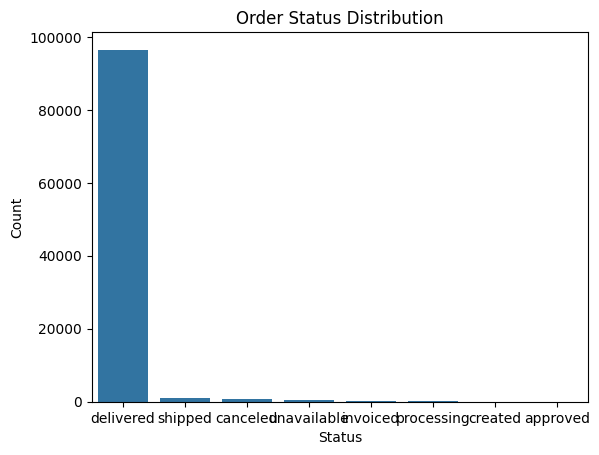

In [128]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Point to your project folder
os.chdir("C:/Users/HP/Downloads/ecommerce-analytics-project")

# Ensure images folder exists
os.makedirs("images", exist_ok=True)

# Example: Order status distribution
sns.countplot(x="order_status", data=orders, order=orders['order_status'].value_counts().index)
plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

# Save BEFORE closing
plt.savefig("images/order_status.png", dpi=300, bbox_inches="tight")

# Show in notebook (optional)
plt.show()

# Close only if looping through many plots
plt.close()


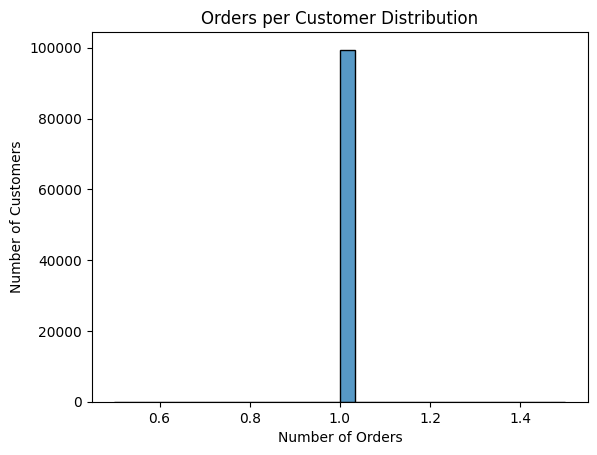

In [129]:
#. Customers
# Orders per customer

# Count orders per customer
orders_per_customer = orders['customer_id'].value_counts()

sns.histplot(orders_per_customer, bins=30, kde=False)
plt.title("Orders per Customer Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

# Save BEFORE closing
plt.savefig("images/orders_per_customer.png", dpi=300, bbox_inches="tight")

# Show in notebook (optional)
plt.show()

# Close only if looping through many plots
plt.close()


C:\Users\HP\AppData\Local\Temp\ipykernel_9268\3397186089.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




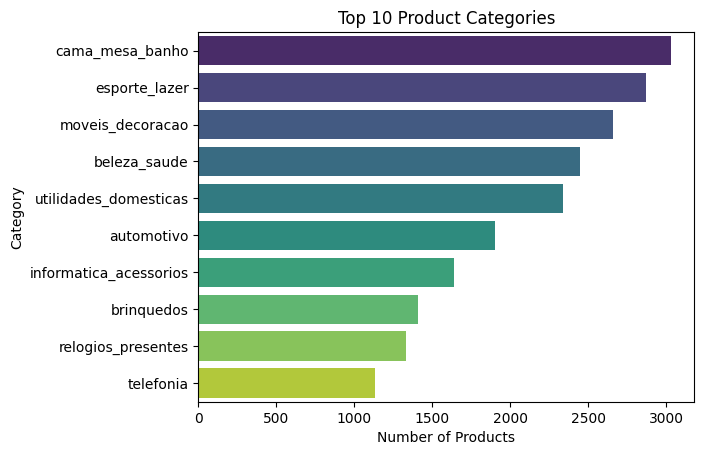

In [130]:
#Products
# Top 10 product categories
# Count top 10 product categories
top_categories = products['product_category_name'].value_counts().head(10)

sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
plt.title("Top 10 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")

# Save BEFORE closing
plt.savefig("images/top_categories.png", dpi=300, bbox_inches="tight")

# Show in notebook (optional)
plt.show()

# Close only if looping through many plots
plt.close()


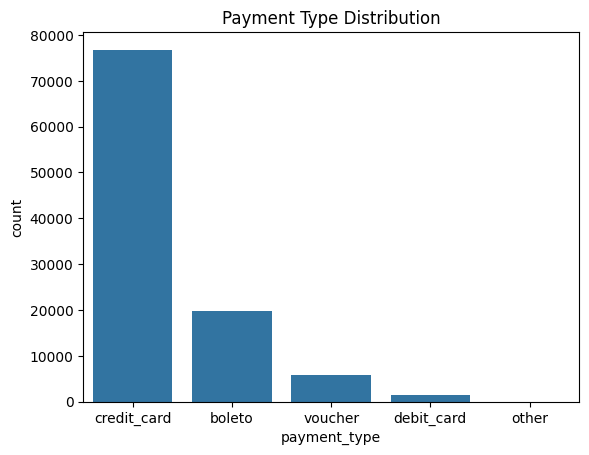

In [107]:
#Payments
# Payment type distribution
sns.countplot(x="payment_type", data=payments, order=payments['payment_type'].value_counts().index)
plt.title("Payment Type Distribution")
plt.show()


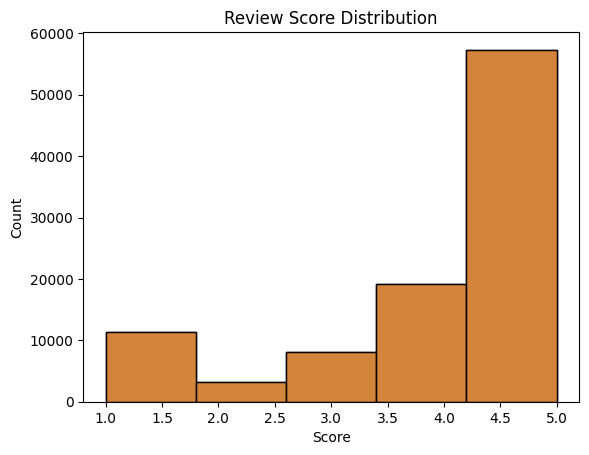

<Figure size 640x480 with 0 Axes>

In [119]:
#Reviews

# Review score histogram
sns.histplot(reviews['review_score'], bins=5, kde=False)
sns.histplot(reviews['review_score'], bins=5, kde=False)
plt.title("Review Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

plt.show()   # Show first
plt.savefig("images/review_scores.png", dpi=300, bbox_inches="tight")


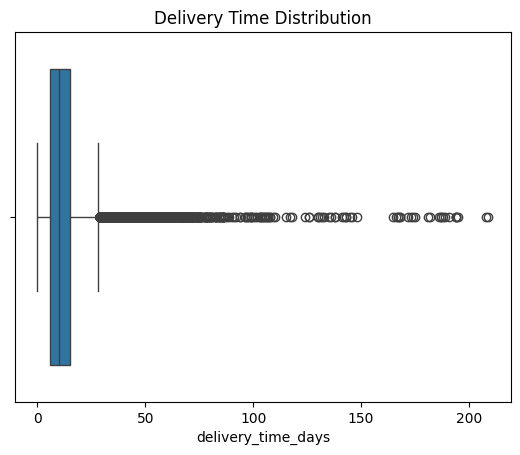

In [109]:
#Delivery Times
# Delivery time in days
orders['delivery_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
sns.boxplot(x=orders['delivery_time_days'])
plt.title("Delivery Time Distribution")
plt.show()


In [121]:
plt.savefig("images/delivery_times.png", dpi=300, bbox_inches="tight")
plt.close()

In [122]:
import os
print(os.getcwd())


C:\Users\HP
